In [1]:
import mne
from mne.datasets import eegbci
import numpy as np
import matplotlib.pyplot as plt

In [2]:
subject = 1
runs = [3, 4]  # left vs right hand motor imagery runs

raw_fnames = eegbci.load_data(subject, runs)
raw = mne.io.concatenate_raws([mne.io.read_raw_edf(f, preload=True) for f in raw_fnames])
raw_filtered = raw.copy().filter(8., 30., fir_design='firwin')

Extracting EDF parameters from C:\Users\deniz\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R03.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...


c:\Users\deniz\bci-replicate\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Extracting EDF parameters from C:\Users\deniz\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Filtering raw data in 2 contiguous segments
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)



In [3]:
print(raw.info)
print(raw.get_data().shape)
print(raw_filtered.info)
print(raw_filtered.get_data().shape)

<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>
(64, 40000)
<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 8.0 Hz
 lowpass: 30.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>
(64, 40000)


Using matplotlib as 2D backend.


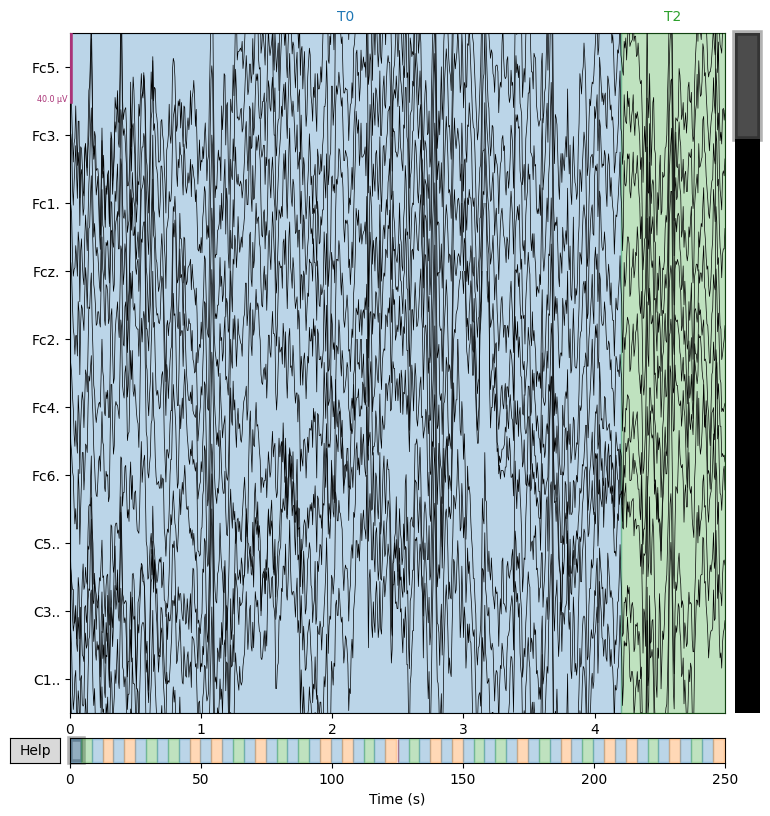

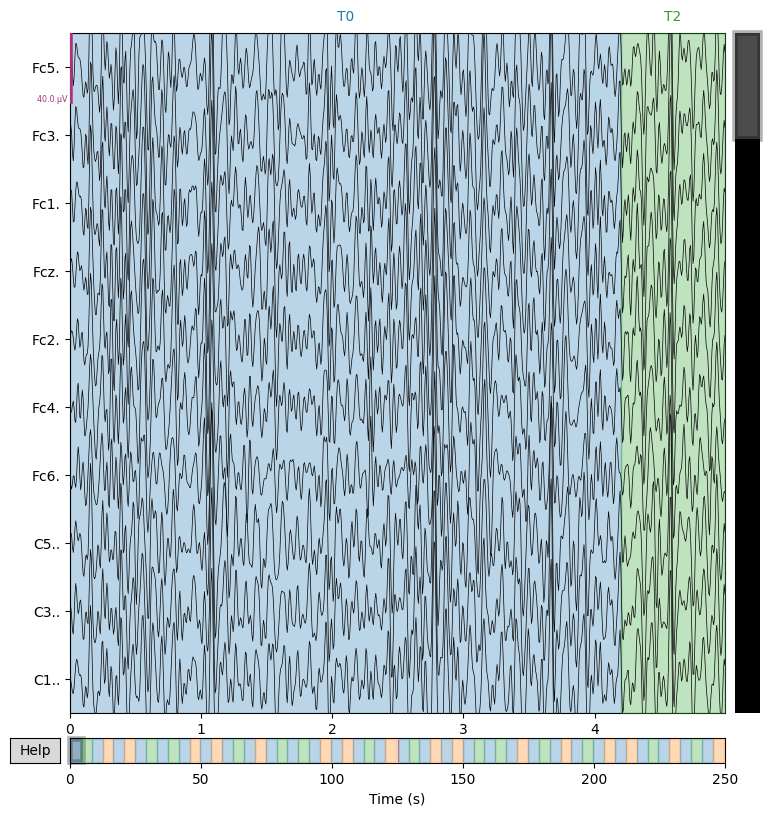

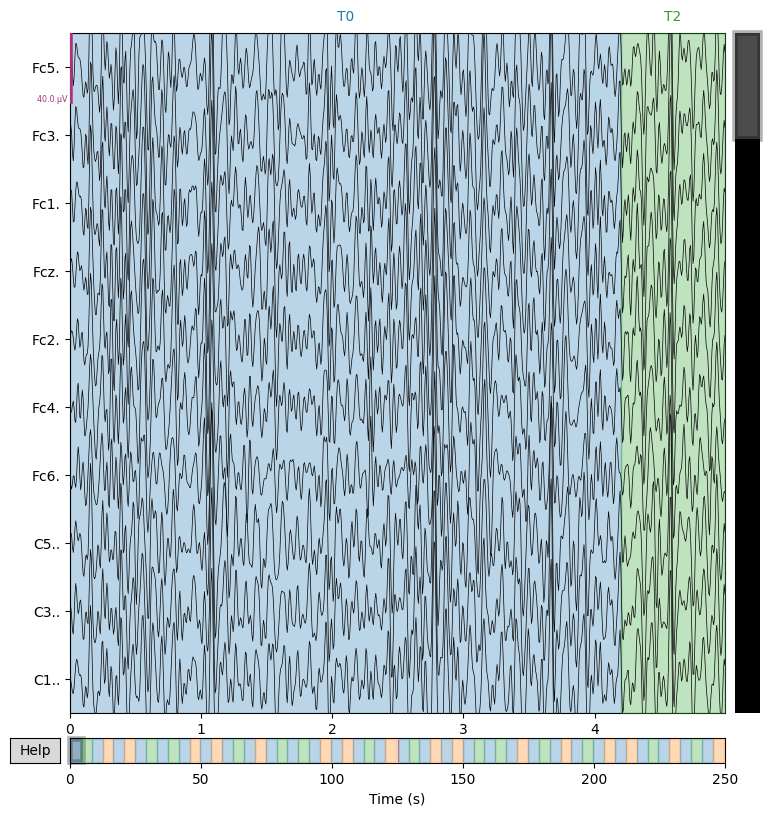

In [4]:
raw.plot(duration=5, n_channels=10)
raw_filtered.plot(duration=5, n_channels=10)

In [5]:
events, event_id = mne.events_from_annotations(raw_filtered)
print(event_id)
print(events[:10])

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}
[[   0    0    1]
 [ 672    0    3]
 [1328    0    1]
 [2000    0    2]
 [2656    0    1]
 [3328    0    2]
 [3984    0    1]
 [4656    0    3]
 [5312    0    1]
 [5984    0    3]]


In [6]:
event_id = dict(left=2, right=3)

epochs = mne.Epochs(
    raw_filtered,
    events,
    event_id=event_id,
    tmin=0.5,
    tmax=2,
    baseline=None,
    preload=True
)

print(epochs)
print(epochs.get_data().shape)

Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 241 original time points ...
0 bad epochs dropped
<Epochs | 30 events (all good), 0.5 – 2 s (baseline off), ~3.6 MiB, data loaded,
 'left': 16
 'right': 14>
(30, 64, 241)


In [7]:
print(len(raw_fnames))
print(epochs.get_data().shape)
print(raw_fnames)

2
(30, 64, 241)
[WindowsPath('C:/Users/deniz/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R03.edf'), WindowsPath('C:/Users/deniz/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R04.edf')]


In [8]:

X = epochs.get_data()  
y = epochs.events[:, -1]

print(X.shape)
print(y.shape)
""""
X_features = np.var(X, axis=2)
print(X_features.shape)


motor_channels = ['C3..', 'C4..', 'Cz..', 'Cp3.', 'Cp4.', 'Fc3.', 'Fc4.']

epochs_motor = epochs.copy().pick_channels(motor_channels)

X_motor = epochs_motor.get_data()
X_motor_features = np.var(X_motor, axis=2)

print(X_motor_features.shape)
"""""
X = epochs.get_data()
y = epochs.events[:, -1]
y = y - 2   # convert 2/3 to 0/1

(30, 64, 241)
(30,)


In [9]:
"""""
y = epochs.events[:, -1]
y = y - 2   # converts 2→0 and 3→1

print(np.unique(y))
"""""

'""\ny = epochs.events[:, -1]\ny = y - 2   # converts 2→0 and 3→1\n\nprint(np.unique(y))\n'

In [10]:
"""""
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
"""""

'""\nfrom sklearn.model_selection import train_test_split\n\nX_train, X_test, y_train, y_test = train_test_split(\n    X, y, \n    test_size=0.2, \n    random_state=42,\n    stratify=y\n)\n\nprint(X_train.shape)\nprint(X_test.shape)\n'

In [11]:
"""""
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)
"""""

'""\nfrom sklearn.linear_model import LogisticRegression\nfrom sklearn.metrics import accuracy_score\n\nmodel = LogisticRegression(max_iter=1000)\n\nmodel.fit(X_train, y_train)\n\ny_pred = model.predict(X_test)\n\naccuracy = accuracy_score(y_test, y_pred)\n\nprint("Test Accuracy:", accuracy)\n'

In [12]:
"""""
print("Mean variance per class:")
print("Left mean:", X_features[y == 0].mean())
print("Right mean:", X_features[y == 1].mean())
"""""

'""\nprint("Mean variance per class:")\nprint("Left mean:", X_features[y == 0].mean())\nprint("Right mean:", X_features[y == 1].mean())\n'

In [13]:
#print(epochs.ch_names)

In [14]:
"""""
from mne.decoding import CSP
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

csp = CSP(n_components=4, log=True)

clf = Pipeline([
    ('csp', csp),
    ('logreg', LogisticRegression(max_iter=1000))
])

scores = cross_val_score(clf, X, y, cv=5)

print("Cross-validation accuracy:", scores.mean())
"""""

'""\nfrom mne.decoding import CSP\nfrom sklearn.pipeline import Pipeline\nfrom sklearn.model_selection import cross_val_score\nfrom sklearn.linear_model import LogisticRegression\n\ncsp = CSP(n_components=4, log=True)\n\nclf = Pipeline([\n    (\'csp\', csp),\n    (\'logreg\', LogisticRegression(max_iter=1000))\n])\n\nscores = cross_val_score(clf, X, y, cv=5)\n\nprint("Cross-validation accuracy:", scores.mean())\n'

In [15]:

from matplotlib.pyplot import clf
from mne.decoding import CSP
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

pipeline = Pipeline([
    ('csp', CSP(n_components=9, log=True)),
    ('svm', SVC())
])

param_grid = {
    'svm__kernel': ['linear', 'rbf'],
    'svm__C': [0.1, 1, 10]
}

grid = GridSearchCV(pipeline, param_grid, cv=5)
grid.fit(X, y)

print("Best score:", grid.best_score_)
print("Best params:", grid.best_params_)


Computing rank from data with rank=None
    Using tolerance 0.00014 (2.2e-16 eps * 64 dim * 9.6e+09  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00013 (2.2e-16 eps * 64 dim * 9.4e+09  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00013 (2.2e-16 eps * 64 dim * 9.5e+09  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMP

In [16]:
best_model = grid.best_estimator_
scores = cross_val_score(best_model, X, y, cv=5)
print(scores.mean())

Computing rank from data with rank=None
    Using tolerance 0.00014 (2.2e-16 eps * 64 dim * 9.6e+09  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00013 (2.2e-16 eps * 64 dim * 9.4e+09  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00013 (2.2e-16 eps * 64 dim * 9.5e+09  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMP

In [17]:
print("runs:", runs)
print("band:", "8-12 Hz")
print("window:", "0.5–2.0 s")
print("best params:", grid.best_params_)
print("best cv score:", grid.best_score_)

runs: [3, 4]
band: 8-12 Hz
window: 0.5–2.0 s
best params: {'svm__C': 10, 'svm__kernel': 'rbf'}
best cv score: 0.9
